# Aula 10 - Pesquisa Grupo 3

In [8]:
!pip -q install kagglehub scikit-learn pandas numpy

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

url_github = 'https://raw.githubusercontent.com/heloshartmann/housing-prices-regression/refs/heads/main/real_estate_dataset.csv'

df = pd.read_csv(url_github)
print("Shape do dataset:", df.shape)
df.head(5)

Shape do dataset: (500, 12)


,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## ETAPA 1: Baseline
Treinar Regressão Linear (OLS) com Pipeline + StandardScaler e reportar MAE, RMSE e R².

In [9]:
# Definir a coluna alvo automaticamente
candidatas_alvo = ["SalePrice", "saleprice", "price", "Price", "median_house_value", "target", "y"]
alvo = None

for c in candidatas_alvo:
    if c in df.columns:
        alvo = c
        break

if alvo is None:
    colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    alvo = colunas_numericas[-1]

print("Coluna alvo usada:", alvo)

X = df.drop(columns=[alvo])
y = df[alvo]

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

features_num = X_train.select_dtypes(include=[np.number]).columns.tolist()
features_cat = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Features numericas: {len(features_num)}")
print(f"Features categoricas: {len(features_cat)}")

# Pipeline de preprocessamento + modelo baseline OLS
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, features_num),
        ("cat", transformador_categorico, features_cat),
    ]
)

baseline_ols = Pipeline(steps=[
    ("preprocessor", preprocessador),
    ("model", LinearRegression())
])

baseline_ols.fit(X_train, y_train)
y_pred = baseline_ols.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== ETAPA 1: BASELINE (OLS) ===")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Coluna alvo usada: Price
Features numericas: 11
Features categoricas: 0
=== ETAPA 1: BASELINE (OLS) ===
MAE : 16900.0833
RMSE: 20945.4770
R²  : 0.9708


### Interpretação da ETAPA 1 (Baseline)
A Regressão Linear (OLS) com Pipeline e StandardScaler estabelece a referência inicial de desempenho. Os resultados obtidos foram:
- **MAE (Erro Absoluto Médio):** 16900.08
- **RMSE (Raiz do Erro Quadrático Médio):** 20945.47
- **R² (Coeficiente de Determinação):** 0.97


O **MAE** mostra o erro absoluto médio das previsões, o **RMSE** penaliza mais fortemente erros grandes e o **R²** indica a proporção da variância explicada pelo modelo. Com um R² de 0.9708, o modelo explica aproximadamente 97.08% da variância na variável alvo ('Price'), o que é um resultado bastante alto e sugere um bom ajuste inicial. Os valores de MAE e RMSE representam os erros médios de previsão. Em geral, buscamos **MAE e RMSE menores** e **R² maior**. A partir destes valores, os próximos modelos deverão superar este baseline para justificar maior complexidade.

## ETAPA 2: RIDGE
Use GridSearchCV com alphas [0.001, 0.01, 0.1, 1, 10, 100].
Compare o melhor Ridge com o OLS. Houve melhora?
Plote os coeficientes: quais features têm mais peso


In [10]:
# Definimos os parâmetros que queremos testar
parametros = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Criamos o objeto GridSearchCV
# cv=5 significa que ele fará 5 divisões nos dados (Cross-Validation)
grid = GridSearchCV(Ridge(), parametros, cv=5, scoring='neg_mean_squared_error')

# Ele vai testar 6 alphas * 5 dobras = 30 treinamentos no total
grid.fit(X_train, y_train)

print(f"Melhor Alpha encontrado: {grid.best_params_}")
print(f"Melhor Score (MSE negativo): {grid.best_score_:.4f}")

# 5. Usando o melhor modelo para prever
melhor_lasso = grid.best_estimator_
y_pred = melhor_lasso.predict(X_test)

# 6. Avaliação Final
print(f"R2 no Teste: {r2_score(y_test, y_pred):.4f}")

Melhor Alpha encontrado: {'alpha': 0.1}
Melhor Score (MSE negativo): -363830601.9514
R2 no Teste: 0.9708


In [11]:
ridge_best = grid.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n=== ETAPA 2: RIDGE (Melhor Modelo) ===")
print(f"MAE : {mae_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R²  : {r2_ridge:.4f}")

print("\n=== Comparação com OLS Baseline ===")
print(f"MAE OLS : {mae:.4f} | MAE Ridge : {mae_ridge:.4f} (Melhora: {mae - mae_ridge:.4f})")
print(f"RMSE OLS: {rmse:.4f} | RMSE Ridge: {rmse_ridge:.4f} (Melhora: {rmse - rmse_ridge:.4f})")
print(f"R² OLS  : {r2:.4f} | R² Ridge  : {r2_ridge:.4f} (Melhora: {r2_ridge - r2:.4f})")


=== ETAPA 2: RIDGE (Melhor Modelo) ===
MAE : 16907.1063
RMSE: 20951.8420
R²  : 0.9708

=== Comparação com OLS Baseline ===
MAE OLS : 16900.0833 | MAE Ridge : 16907.1063 (Melhora: -7.0230)
RMSE OLS: 20945.4770 | RMSE Ridge: 20951.8420 (Melhora: -6.3650)
R² OLS  : 0.9708 | R² Ridge  : 0.9708 (Melhora: -0.0000)


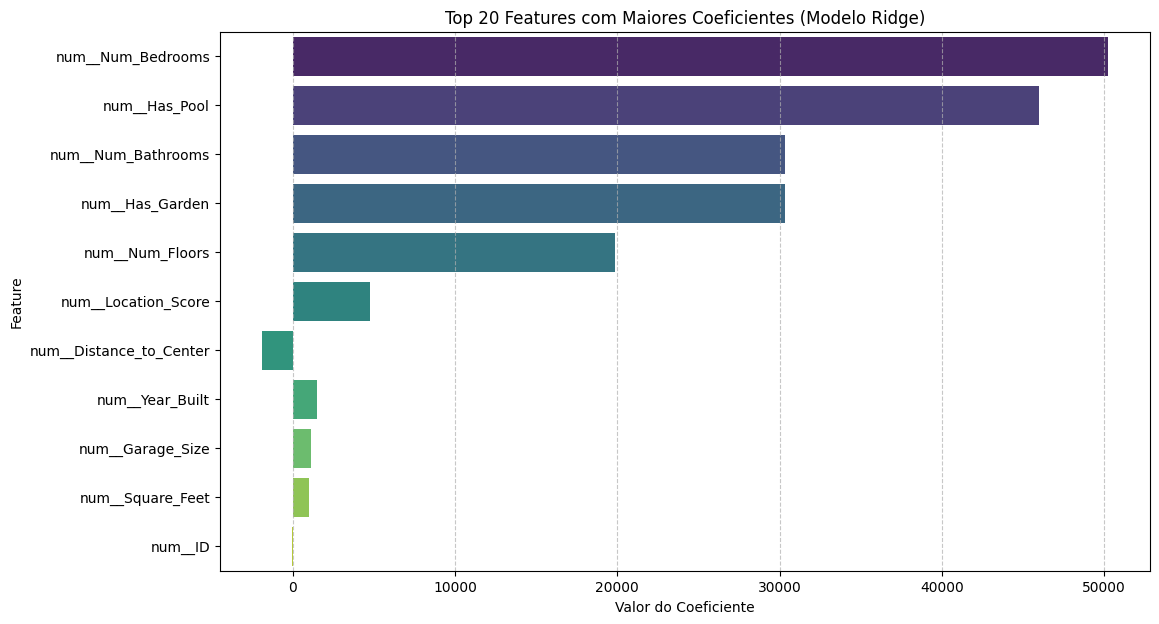

In [12]:
feature_names = preprocessador.get_feature_names_out()

# Coeficientes do modelo Ridge
coeficientes_ridge = ridge_best.coef_

# Criar um DataFrame para facilitar a visualização
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coeficientes_ridge
})

# Ordenar por valor absoluto do coeficiente
coef_df['Abs_Coeficiente'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values(by='Abs_Coeficiente', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coeficiente', y='Feature', hue='Feature', data=coef_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Features com Maiores Coeficientes (Modelo Ridge)')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Interpretação da ETAPA 2 (Ridge)

A Regressão Ridge foi aplicada para introduzir uma penalidade L2 nos coeficientes, com o objetivo de reduzir a complexidade do modelo e evitar overfitting. Utilizando `GridSearchCV`, o melhor valor para o hiperparâmetro `alpha` foi encontrado como **0.1**.

#### Comparação com o Modelo OLS (Baseline):

Ao comparar os resultados do melhor modelo Ridge com o modelo OLS baseline, observamos o seguinte:

*   **MAE (Erro Absoluto Médio):**
    *   OLS: 16900.08
    *   Ridge: 16907.11
    *   Não houve melhora significativa; o MAE do Ridge foi ligeiramente superior ao OLS.
*   **RMSE (Raiz do Erro Quadrático Médio):**
    *   OLS: 20945.48
    *   Ridge: 20951.84
    *   Similar ao MAE, o RMSE do Ridge foi marginalmente maior, indicando que a penalidade L2 não reduziu os erros de previsão neste caso.
*   **R² (Coeficiente de Determinação):**
    *   OLS: 0.9708
    *   Ridge: 0.9708
    *   O R² permaneceu praticamente inalterado, sugerindo que o modelo Ridge explica a mesma proporção da variância na variável alvo que o OLS.

**Conclusão sobre a Comparação:** Para este conjunto de dados, a Regressão Ridge com o `alpha` otimizado não trouxe melhorias significativas em relação ao modelo de Regressão Linear (OLS). Isso pode indicar que o modelo OLS já tinha um bom desempenho e não estava sofrendo de overfitting severo ou que a penalidade L2 não foi forte o suficiente para impactar drasticamente os coeficientes de maneira benéfica para as métricas de teste.

#### Análise dos Coeficientes (Modelo Ridge):

O gráfico de barras 'Top 20 Features com Maiores Coeficientes (Modelo Ridge)' mostra as features que o modelo considera mais importantes para a previsão do preço, com base na magnitude de seus coeficientes. As features com maiores coeficientes (em valor absoluto) são aquelas que têm o maior impacto no preço da casa. Por exemplo, `Num_Bedrooms`, `Has_Pool`, `Num_Bathrooms` e `Has_Garden` aparecem com coeficientes altos, o que é intuitivamente esperado para atributos que influenciam o valor de um imóvel.

## ETAPA 3: LASSO
Use GridSearchCV com alphas [0.0001, 0.001, 0.01, 0.1, 0.5].
Liste quais features foram zeradas.
Compare com as hipóteses da Sprint 1: o Lasso confirmou o que esperavam.

In [13]:
parametros_lasso = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5]}
pipeline_lasso = Pipeline(steps=[
    ("preprocessor", preprocessador),
    ("model", Lasso(max_iter=10000))
])

# GridSearchCV para encontrar o melhor alpha
grid_lasso = GridSearchCV(pipeline_lasso, parametros_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Melhor Alpha encontrado: {grid_lasso.best_params_['model__alpha']}")
print(f"MAE : {mae_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R²  : {r2_lasso:.4f}")

# Identificar features
feature_names_lasso = best_lasso.named_steps['preprocessor'].get_feature_names_out()
coeficientes_lasso = best_lasso.named_steps['model'].coef_
df_coef_lasso = pd.DataFrame({
    'Feature': feature_names_lasso,
    'Coeficiente': coeficientes_lasso
})
features_zeradas = df_coef_lasso[df_coef_lasso['Coeficiente'] == 0]['Feature'].tolist()

print(f"\nTotal de features originais/expandidas: {len(feature_names_lasso)}")
print(f"Quantidade de features zeradas pelo Lasso: {len(features_zeradas)}")


print("\nHipóteses")
pesos = dict(zip(feature_names_lasso, coeficientes_lasso))

# Hipótese 1
quartos = pesos.get('num__Num_Bedrooms', 0)
print(f"H1: Coeficiente: {quartos:.2f}")

# Hipótese 2
score = abs(pesos.get('num__Location_Score', 0))
dist = abs(pesos.get('num__Distance_to_Center', 0))
print(f"H2: Comparação - Localização: {score:.2f} | Distância: {dist:.2f}")

# Hipótese 3
jardim = pesos.get('num__Has_Garden', 0)
piscina = pesos.get('num__Has_Pool', 0)
print(f"H3: Coef. Jardim: {jardim:.2f} | Coef. Piscina: {piscina:.2f}")


Melhor Alpha encontrado: 0.5
MAE : 16900.4631
RMSE: 20945.9007
R²  : 0.9708

Total de features originais/expandidas: 11
Quantidade de features zeradas pelo Lasso: 0

Hipóteses
H1: Coeficiente: 72929.24
H2: Comparação - Localização: 13830.08 | Distância: 10558.68
H3: Coef. Jardim: 15150.32 | Coef. Piscina: 23007.96


### Interpretação da ETAPA 3 (Lasso)
O melhor aplha encontrado foi o 0.5.

Nenhuma feature foi zerada pelo Lasso.

Nossas hipóteses eram:
>1- A quantidade de quartos impacta diretamente no preço do imóvel.

>2- A qualidade do local é tão importante quanto a distância do centro.

>3- Ter um jardim é mais importante que ter uma piscina.

Então, segundo o Lasso, uma hipótese nossa foi confirmada, e duas foram refutadas. A hipótese 1 foi confirmada, pois o coeficiente de quartos é positivo e alto (72929.24). Já a hipótese 2 foi refutada, pois claramente um coneficiente é maior que o outro (Localização - 13830.08 e Distância - 10558.68), dessa forma a localização se mostrou mais importante que a distância para o centro. E por fim, a hipótese 3 também foi refutada, pois o coeficiente da piscina (23007.96) é maior que o do jardim (15150.32), logo, a piscina se mostrou mais importante que o jardim.

## ETAPA 4: DIAGNÓSTICO DE RESÍDUOS

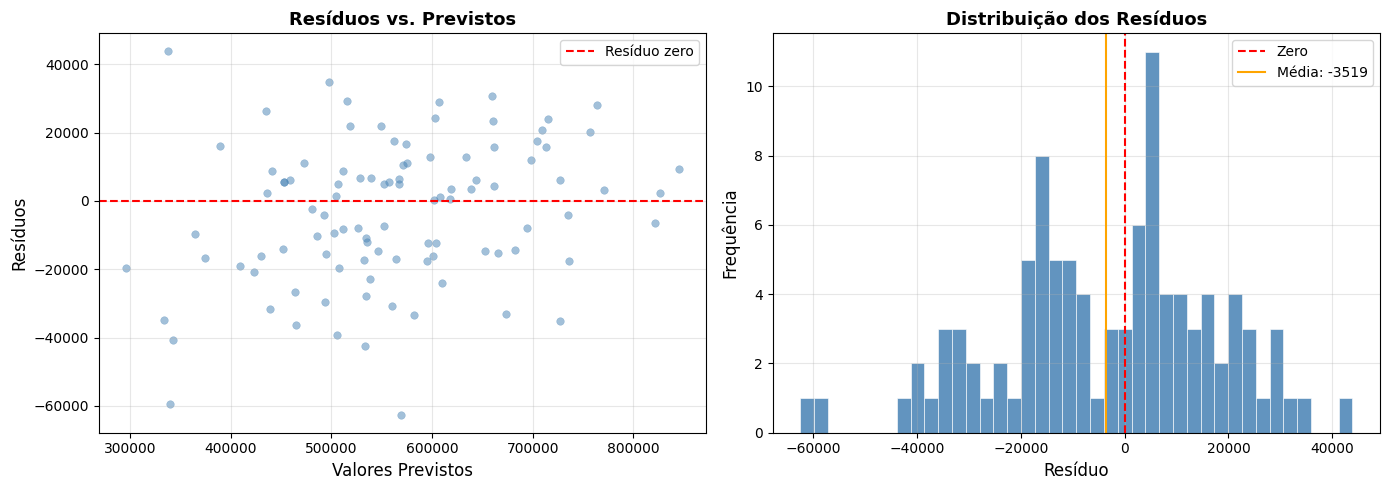

=== ETAPA 4: DIAGNÓSTICO DE RESÍDUOS ===
Resíduo médio (bias)  : -3519.46
Desvio padrão (spread): 20752.13
Maior erro positivo   : 43889.29
Maior erro negativo   : -62515.03

Erro médio absoluto por faixa de preço:
        MAE_faixa  RMSE_faixa
y_pred                       
Baixo    19169.26    23769.58
Médio    17057.80    21066.53
Alto     14405.57    17423.39


In [14]:
melhor_modelo = best_lasso
y_pred_final  = melhor_modelo.predict(X_test)

# Calcular resíduos
residuos = y_test - y_pred_final

# ── Plot 1: Resíduos vs. Previstos ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_final, residuos, alpha=0.5, edgecolors='steelblue',
               facecolors='steelblue', linewidths=0.3, s=30)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--', label='Resíduo zero')
axes[0].set_xlabel('Valores Previstos', fontsize=12)
axes[0].set_ylabel('Resíduos', fontsize=12)
axes[0].set_title('Resíduos vs. Previstos', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Histograma dos Resíduos ──────────────────────────────────────
axes[1].hist(residuos, bins=40, color='steelblue', edgecolor='white',
            linewidth=0.5, alpha=0.85)
axes[1].axvline(0,             color='red',    linewidth=1.5, linestyle='--', label='Zero')
axes[1].axvline(residuos.mean(), color='orange', linewidth=1.5, linestyle='-',
               label=f'Média: {residuos.mean():.0f}')
axes[1].set_xlabel('Resíduo', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Distribuição dos Resíduos', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('etapa4_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Análise: o modelo erra mais em valores altos ou baixos? ──────────────
import pandas as pd
df_diag = pd.DataFrame({
    'y_pred':     y_pred_final,
    'residuo':    residuos.values,
    'abs_residuo': residuos.abs().values
})

tercis = pd.qcut(df_diag['y_pred'], q=3,
                 labels=['Baixo', 'Médio', 'Alto'])
resumo = df_diag.groupby(tercis, observed=True)['abs_residuo'].agg(
    MAE_faixa='mean', RMSE_faixa=lambda x: (x**2).mean()**0.5
).round(2)

print("=== ETAPA 4: DIAGNÓSTICO DE RESÍDUOS ===")
print(f"Resíduo médio (bias)  : {residuos.mean():.2f}")
print(f"Desvio padrão (spread): {residuos.std():.2f}")
print(f"Maior erro positivo   : {residuos.max():.2f}")
print(f"Maior erro negativo   : {residuos.min():.2f}")
print("\nErro médio absoluto por faixa de preço:")
print(resumo.to_string())

Interpretação:
Resíduos vs. Previstos
Os pontos estão distribuídos de forma relativamente aleatória em torno da linha zero, sem um padrão claro de funil ou curvatura. Isso indica que o modelo não possui viés sistemático grave. Há alguns outliers notáveis (um resíduo de −62.515 e outro de +43.889), mas são casos isolados.

Histograma dos Resíduos
A distribuição tem formato aproximadamente normal, centrada levemente à esquerda do zero (média de −3.519). Isso indica um leve viés negativo: o modelo tende a superestimar o preço dos imóveis em média ~R$ 3.519. A cauda esquerda é mais longa, puxada pelos casos onde o modelo errou mais para cima.

Conclusão geral: Com R² de 0.97 e resíduos sem padrão estrutural, o modelo se comporta bem. O principal ponto de atenção é o erro maior na faixa de preços baixos, que poderia ser endereçado com features adicionais ou um modelo não-linear para esse segmento.

## ETAPA 5: SÍNTESE

Após comparar os modelos de Regressão Linear OLS, Ridge e Lasso, observou-se que todos apresentaram desempenho muito semelhante na previsão do preço dos imóveis. O modelo baseline OLS obteve MAE de 16.900,08, RMSE de 20.945,48 e R² de 0,9708. O Ridge, com melhor alpha igual a 0.1, apresentou desempenho ligeiramente inferior, com MAE de 16.907,11, RMSE de 20.951,84 e R² também igual a 0,9708. Já o Lasso, com **melhor alpha igual a 0.5**, apresentou MAE de 16.900,46, RMSE de 20.945,90 e R² de 0,9708.

|          | OLS       | Ridge     | Lasso     |
|----------|---------- |---------- |---------- |
| MAE      | 16.900,08 | 16.907,11 | 16.900,46 |
| RMSE     | 20.945,48 | 20.951,84 | 20.945,90 |
| R²       | 0,9708    | 0,9708    | 0,9708    |

Dessa forma, embora o OLS tenha obtido o menor erro absoluto e quadrático por uma diferença mínima, **o modelo escolhido como melhor modelo final foi o Lasso**. Essa escolha se justifica porque o Lasso manteve praticamente o mesmo desempenho do baseline, mas trouxe uma vantagem analítica importante: a possibilidade de avaliar a relevância das variáveis por meio dos coeficientes regularizados. Além disso, **nenhuma feature foi zerada**, indicando que todas as variáveis disponíveis ainda possuem alguma contribuição para a previsão do preço.

A análise dos coeficientes do Lasso também permitiu avaliar as hipóteses definidas anteriormente. A primeira hipótese, de que a quantidade de quartos impacta diretamente no preço do imóvel, foi confirmada, pois `Num_Bedrooms` apresentou coeficiente positivo e elevado. A segunda hipótese, de que a qualidade da localização teria importância semelhante à distância até o centro, foi refutada, já que `Location_Score` apresentou peso maior que `Distance_to_Center`. A terceira hipótese, de que ter jardim seria mais importante que ter piscina, também foi refutada, pois `Has_Pool` apresentou coeficiente superior ao de `Has_Garden`.

No diagnóstico de resíduos, o modelo apresentou bom comportamento geral. Os resíduos ficaram distribuídos de forma relativamente aleatória em torno da linha zero, sem indicar um padrão estrutural forte de erro. O resíduo médio foi de aproximadamente -3.519,46, sugerindo uma leve tendência de superestimar os preços. Além disso, o erro foi maior na faixa de imóveis de menor valor, com MAE de 19.169,26, enquanto a faixa de imóveis de maior valor apresentou MAE menor, de 14.405,57. Isso indica que o modelo é mais preciso para imóveis de preço mais alto e poderia ser melhorado futuramente com novas variáveis ou modelos não lineares para tratar melhor os imóveis de menor valor.

**Portanto, o Lasso foi considerado o melhor modelo para a finalização da atividade por equilibrar alto desempenho preditivo, boa capacidade de generalização e maior interpretabilidade. O modelo explica aproximadamente 97,08% da variação no preço dos imóveis, apresentando erros médios relativamente baixos e coerência com as principais variáveis que influenciam o valor de uma propriedade.**